29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 01/15 | loss=0.7431 | train_acc=0.8161 | val_acc=0.8122 | time=22.75s
Epoch 02/15 | loss=0.5204 | train_acc=0.8374 | val_acc=0.8382 | time=8.82s
Epoch 03/15 | loss=0.4775 | train_acc=0.8450 | val_acc=0.8412 | time=11.00s
Epoch 04/15 | loss=0.4555 | train_acc=0.8478 | val_acc=0.8478 | time=8.14s
Epoch 05/15 | loss=0.4397 | train_acc=0.8535 | val_acc=0.8500 | time=8.82s
Epoch 06/15 | loss=0.4317 | train_acc=0.8532 | val_acc=0.8514 | time=8.82s
Epoch 07/15 | loss=0.4242 | train_acc=0.8582 | val_acc=0.8528 | time=8.96s
Epoch 08/15 | loss=0.4163 | train_acc=0.8601 | val_acc=0.8552 | time=9.19s
Epoch 09/15 | loss=0.4115 | train_acc=0.8598 | val_acc=0.8544 | time=8.77s
Epoch 10/15 | loss=0.4075 | train_acc=0.8620 | val_acc=0.8580 | time=10.43s
Epoch 11/15 | loss=0.4030 | train_acc=0.8627 | val_acc=0.85

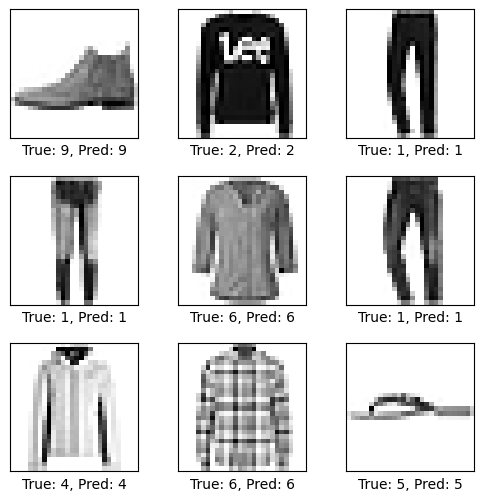

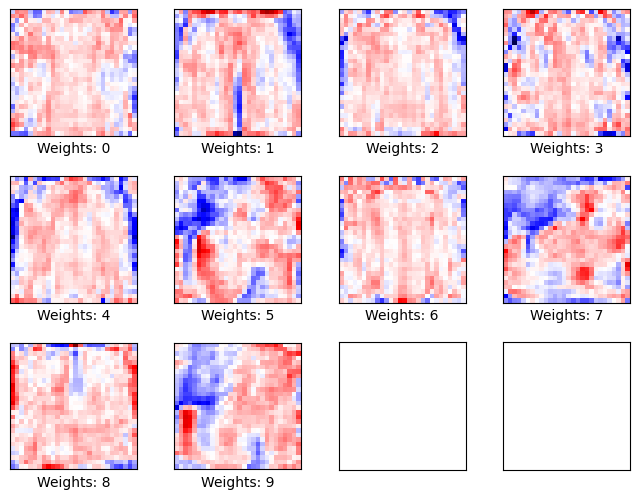

In [ ]:
"""
author:-aam35
Logistic regression (linear classifier) on Fashion-MNIST using TF eager execution (TF2 style).
No Keras model/layers used for the model itself (only tf.Variable, tf.matmul, GradientTape).
"""
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Hyperparameters (you can tune these) ---
learning_rate = 0.001
batch_size = 128
n_epochs = 15
# ------------------------------

# Ensure eager mode (TF2 default). If running in TF1.x with compat, uncomment below:
# tf.compat.v1.enable_eager_execution()

# Step 1: Read in data (using tf.keras.datasets convenience loader)
# If you have your own utils.read_fmnist, replace this block.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Normalize to [0,1]
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32)  / 255.0

# Flatten images (28*28 = 784)
img_shape = (28, 28)
img_size_flat = 28 * 28
n_classes = 10

x_train = x_train.reshape([-1, img_size_flat])
x_test  = x_test.reshape([-1, img_size_flat])

n_train = x_train.shape[0]
n_test  = x_test.shape[0]

# Convert labels to one-hot
y_train_oh = tf.one_hot(y_train, depth=n_classes)
y_test_oh  = tf.one_hot(y_test, depth=n_classes)

# Create train/val split (e.g., 55k train + 5k val)
val_size = 5000
x_val = x_train[-val_size:]
y_val_oh = y_train_oh[-val_size:]
y_val = y_train[-val_size:]

x_train = x_train[:-val_size]
y_train_oh = y_train_oh[:-val_size]
y_train = y_train[:-val_size]
n_train = x_train.shape[0]

# Step 2: Create tf.data datasets and batching
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train_oh))
train_dataset = train_dataset.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val_oh)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test_oh)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Step 3: create weights and bias
# w shape: (img_size_flat, n_classes)
# b shape: (n_classes,)
initializer = tf.initializers.RandomNormal(mean=0.0, stddev=0.01)
w = tf.Variable(initializer([img_size_flat, n_classes]), dtype=tf.float32)
b = tf.Variable(tf.zeros([n_classes]), dtype=tf.float32)

# Step 4: build model (function returns logits)
def model_logits(x):
    # x: [batch, img_size_flat]
    return tf.matmul(x, w) + b

# Step 5: define loss function (softmax cross entropy)
def loss_fn(logits, labels_onehot):
    # returns scalar average loss over batch
    per_example = tf.nn.softmax_cross_entropy_with_logits(labels=labels_onehot, logits=logits)
    return tf.reduce_mean(per_example)

# Step 6: define optimizer
optimizer = tf.optimizers.Adam(learning_rate=learning_rate)

# Step 7: accuracy helper
def compute_accuracy(dataset):
    correct = 0
    total = 0
    for x_batch, y_batch_oh in dataset:
        logits = model_logits(x_batch)
        preds = tf.nn.softmax(logits)
        pred_labels = tf.argmax(preds, axis=1).numpy()
        true_labels = tf.argmax(y_batch_oh, axis=1).numpy()
        correct += np.sum(pred_labels == true_labels)
        total += x_batch.shape[0]
    return correct / total

# Step 8: train the model for n_epochs times
for epoch in range(1, n_epochs + 1):
    t0 = time.time()
    total_loss = 0.0
    n_batches = 0
    for x_batch, y_batch_oh in train_dataset:
        with tf.GradientTape() as tape:
            logits = model_logits(x_batch)
            loss = loss_fn(logits, y_batch_oh)
        grads = tape.gradient(loss, [w, b])
        optimizer.apply_gradients(zip(grads, [w, b]))

        total_loss += loss.numpy()
        n_batches += 1

    train_loss = total_loss / n_batches
    train_acc = compute_accuracy(train_dataset)
    val_acc = compute_accuracy(val_dataset)
    t1 = time.time()

    print(f"Epoch {epoch:02d}/{n_epochs} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | time={t1-t0:.2f}s")

# Step 9: Get the Final test accuracy
test_acc = compute_accuracy(test_dataset)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Confusion matrix on test set (optional)
all_preds = []
all_trues = []
for x_batch, y_batch_oh in test_dataset:
    logits = model_logits(x_batch)
    pred_labels = tf.argmax(tf.nn.softmax(logits), axis=1).numpy()
    true_labels = tf.argmax(y_batch_oh, axis=1).numpy()
    all_preds.append(pred_labels)
    all_trues.append(true_labels)

all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)
cm = confusion_matrix(all_trues, all_preds)
print("\nConfusion matrix (test):")
print(cm)

# Step 10: Helper function to plot images in 3*3 grid
def plot_images(images, y, yhat=None):
    assert len(images) == len(y) == 9
    fig, axes = plt.subplots(3, 3, figsize=(6,6))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].reshape(img_shape), cmap='binary')
        if yhat is None:
            xlabel = f"True: {y[i]}"
        else:
            xlabel = f"True: {y[i]}, Pred: {yhat[i]}"
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

# Get 9 test images for visualization
images_vis = x_test[:9]
y_vis = y_test[:9]
# Predictions
logits_vis = model_logits(images_vis)
preds_vis = tf.argmax(tf.nn.softmax(logits_vis), axis=1).numpy()
plot_images(images=images_vis, y=y_vis, yhat=preds_vis)

# Second plot: weights visualization
def plot_weights(w_var):
    w_val = w_var.numpy()  # shape (img_size_flat, 10)
    w_min = np.min(w_val)
    w_max = np.max(w_val)
    fig, axes = plt.subplots(3, 4, figsize=(8,6))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    for i, ax in enumerate(axes.flat):
        if i < 10:
            image = w_val[:, i].reshape(img_shape)
            ax.set_xlabel(f"Weights: {i}")
            ax.imshow(image, vmin=w_min, vmax=w_max, cmap='seismic')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

plot_weights(w)
